# OHL Goalkeeper Progression — Steps 1–5
**Steps covered:** Load Data → Feature Engineering → Feature Selection → Modelling → Validation

> Central question: *Given a goalkeeper's performance in a lower league, can you predict whether he will make it at a higher level?*

## 0 · Setup

In [5]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')

GK_DATA = Path('Data')         
COMP_DIR = GK_DATA / 'competitions'

print('Data folder:', GK_DATA.resolve())
print('Exists:', GK_DATA.exists())

Data folder: C:\Users\angel\Files\UCLL\Semester 4\Advanced AI\Project\Data
Exists: True


---
## Step 1 · Load Data

### 1a · Labels

In [6]:
df = pd.read_csv(GK_DATA / 'gk_dataset_final.csv')

print(f'Total keepers: {len(df)}')
print('\nStatus distribution:')
print(df['status'].value_counts())
print('\nDirection distribution:')
print(df['direction'].value_counts())

df.head(3)

Total keepers: 693

Status distribution:
status
STAYED     435
DROPPED    128
PLAYS       99
BENCH       31
Name: count, dtype: int64

Direction distribution:
direction
NONE    435
UP      130
DOWN    128
Name: count, dtype: int64


,playerId,name,age,birthdate,status,origin_team,origin_comp,origin_season,origin_median,origin_matches,current_team,current_comp,current_season,current_median,current_matches,step,direction,origin_match_dirs,current_match_dirs
0,1353,Nils Körber,29.0,1996-11-13,BENCH,SpVgg Greuther Fürth II,regionalliga_bayern,2023-2024,0.287193,1,FC Hansa Rostock,bundesliga_2,2023-2024,0.710515,1.0,0.423322,UP,20240219 FC Bayern München II - SpVgg Greuthe...,20240120 1. FC Nürnberg - FC Hansa Rostock
1,126501,Paul Argney,19.0,2006-05-23,BENCH,Royal Francs Borains,challenger_pro_league,2024-2025,0.348513,1,Le Havre AC,ligue1,2025-2026,0.771221,1.0,0.422708,UP,20250406 RAAL La Louvière - Royal Francs Borains,20260104 Le Havre AC - Angers SCO
2,178234,Pape Sy,28.0,1997-05-02,BENCH,RFC Seraing,challenger_pro_league,2023-2024,0.348513,14,FC Metz,ligue1,2025-2026,0.771221,1.0,0.422708,UP,20230902 KV Oostende - RFC Seraing|20230917 KM...,20251026 LOSC Lille - FC Metz


### 1b · Definition files

In [7]:
with open(GK_DATA / 'player_kpi_definitions.json') as f:
    kpi_defs = {d['id']: d['name'] for d in json.load(f).get('data', [])}

with open(GK_DATA / 'player_score_definitions.json') as f:
    score_defs = {d['id']: d['name'] for d in json.load(f).get('data', [])}

print(f'KPI definitions loaded   : {len(kpi_defs)}')
print(f'Score definitions loaded : {len(score_defs)}')

KPI definitions loaded   : 1458
Score definitions loaded : 134


### 1c · Building a competition folder lookup

Match directories in `origin_match_dirs` are bare folder names like `20230401 Club A - Club B`.  
We index every match folder once so lookups are O(1) instead of scanning 40+ league folders each time.

In [8]:
match_index: dict[str, Path] = {}
for cs_dir in COMP_DIR.iterdir():
    if not cs_dir.is_dir():
        continue
    for match_dir in cs_dir.iterdir():
        if match_dir.is_dir():
            match_index[match_dir.name] = match_dir

print(f'Match folders indexed: {len(match_index):,}')

Match folders indexed: 10,765


### 1d · Loading functions

Two parallel loaders, one for **player_scores** (Level 1, fast) and one for **player_kpis** (Level 2, detailed).  
Both use the shared `match_index` from above and apply the `matchShare >= 0.5` filter.

In [9]:
def parse_match_dirs(raw: str | float) -> list[str]:
    if not isinstance(raw, str) or not raw.strip():
        return []
    return [m.strip() for m in raw.split('|') if m.strip()]


def _iter_players(json_data: dict, squad_key: str):
    yield from json_data.get('data', {}).get(squad_key, {}).get('players', [])


# player_scores loader
def load_keeper_scores(player_id: int, match_dirs_raw: str | float) -> list[dict]:
    records = []
    for mdir in parse_match_dirs(match_dirs_raw):
        match_path = match_index.get(mdir)
        if match_path is None:
            continue

        kpi_path   = match_path / 'player_kpis.json'
        score_path = match_path / 'player_scores.json'
        if not kpi_path.exists() or not score_path.exists():
            continue

        # Step 1: verify player is a GOALKEEPER in player_kpis
        with open(kpi_path) as f:
            kpi_data = json.load(f)

        gk_match_share = None
        for side in ('squadHome', 'squadAway'):
            for p in _iter_players(kpi_data, side):
                if (p.get('id') == player_id
                        and p.get('position') == 'GOALKEEPER'
                        and p.get('matchShare', 0) >= 0.5):
                    gk_match_share = p.get('matchShare')
                    gk_play_duration = p.get('playDuration', 0)
                    break
            if gk_match_share is not None:
                break

        if gk_match_share is None:
            continue   # not a GK or didn't play enough

        # Step 2: grab scores from player_scores.json
        with open(score_path) as f:
            score_data = json.load(f)

        for side in ('squadHome', 'squadAway'):
            for p in _iter_players(score_data, side):
                if p.get('id') == player_id:
                    row = {f'score_{s["playerScoreId"]}': s['value']
                           for s in p.get('playerScores', [])}
                    row['matchShare']   = gk_match_share
                    row['playDuration'] = gk_play_duration
                    records.append(row)
                    break

    return records


# player_kpis loader
def load_keeper_kpis(player_id: int, match_dirs_raw: str | float) -> list[dict]:
    records = []
    for mdir in parse_match_dirs(match_dirs_raw):
        match_path = match_index.get(mdir)
        if match_path is None:
            continue
        kpi_path = match_path / 'player_kpis.json'
        if not kpi_path.exists():
            continue

        with open(kpi_path) as f:
            data = json.load(f).get('data', {})

        for side in ('squadHome', 'squadAway'):
            for p in data.get(side, {}).get('players', []):
                if (p.get('id') == player_id
                        and p.get('position') == 'GOALKEEPER'
                        and p.get('matchShare', 0) >= 0.5):
                    row = {f'kpi_{k["kpiId"]}': k['value'] for k in p.get('kpis', [])}
                    row['matchShare']   = p.get('matchShare')
                    row['playDuration'] = p.get('playDuration', 0)
                    records.append(row)
                    break

    return records


print('Loader functions defined ✓')

Loader functions defined ✓


### 1e · Verification, single keeper

In [10]:
row = df.iloc[0]
scores = load_keeper_scores(row['playerId'], row['origin_match_dirs'])

print(f"Keeper : {row['name']}  (id={row['playerId']})")
print(f"Status : {row['status']}")
print(f"Matches with scores loaded: {len(scores)}")
if scores:
    print(f"Score columns per match   : {len(scores[0])}")
    print("First match (sample):", {k: round(v, 4) for k, v in list(scores[0].items())[:6]})

Keeper : Nils Körber  (id=1353)
Status : BENCH
Matches with scores loaded: 0


---
## Step 2 · Feature Engineering

For each keeper we aggregate all qualifying match records into a single feature vector using **mean** (primary) plus **std** and **match count** as reliability indicators.

### 2a · Build per-keeper feature vectors (player_scores, Level 1)

In [11]:
MIN_MATCHES = 3   # keepers with fewer matches are excluded (unreliable averages)

records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Loading scores'):
    matches = load_keeper_scores(row['playerId'], row['origin_match_dirs'])

    if len(matches) < MIN_MATCHES:
        continue

    match_df = pd.DataFrame(matches)

    # Collect all score columns (exclude metadata columns)
    score_cols = [c for c in match_df.columns if c.startswith('score_')]

    feat = {
        'playerId'       : row['playerId'],
        'name'           : row['name'],
        'status'         : row['status'],
        'direction'      : row['direction'],
        'age'            : row['age'],
        'origin_median'  : row['origin_median'],
        'origin_matches' : row['origin_matches'],
        'n_matches_loaded': len(matches),
    }

    for col in score_cols:
        vals = match_df[col].dropna()
        if len(vals) == 0:
            feat[f'mean_{col}'] = np.nan
            feat[f'std_{col}']  = np.nan
        else:
            feat[f'mean_{col}'] = vals.mean()
            feat[f'std_{col}']  = vals.std()

    records.append(feat)

features_df = pd.DataFrame(records)
print(f'Keepers with ≥{MIN_MATCHES} matches : {len(features_df)}')
print(f'Feature columns              : {len(features_df.columns)}')
print('\nStatus breakdown after filter:')
print(features_df['status'].value_counts())

Loading scores: 100%|██████████| 693/693 [00:15<00:00, 44.78it/s] 

Keepers with ≥3 matches : 218
Feature columns              : 276

Status breakdown after filter:
status
STAYED     117
DROPPED     55
PLAYS       37
BENCH        9
Name: count, dtype: int64


The above filters on the number of matches loaded from origin_match_dirs, which is the match data from the keeper's time at his origin club, before any transfer happened.
So MIN_MATCHES = 3 means: only keep keepers for whom we successfully loaded at least 3 qualifying matches (matchShare ≥ 0.5) at their origin club. Those are the matches used to compute the feature averages.

The reason it drops so many keepers (693 to 218) is a combination of two things:
- Some keepers genuinely played very few matches: particularly BENCH keepers who transferred but never played, or STAYED keepers who were squad players. They physically only appeared in 1–2 matches with matchShare ≥ 0.5.
- Some keepers have match data that simply couldn't be found: the match folder exists but the keeper's ID wasn't in the player_scores.json for that match, or the match folder name didn't match the index. Your sanity check in cell 1e actually showed this — Nils Körber had Matches with scores loaded: 0 despite having origin match dirs listed.

### 2b · Rename score columns to better readable names

In [12]:
def rename_score_cols(df: pd.DataFrame, score_defs: dict) -> pd.DataFrame:
    rename_map = {}
    for col in df.columns:
        for prefix in ('mean_score_', 'std_score_'):
            if col.startswith(prefix):
                sid = int(col.replace(prefix, ''))
                readable = score_defs.get(sid, f'SCORE_{sid}')
                rename_map[col] = col.replace(f'score_{sid}', readable)
    return df.rename(columns=rename_map)

features_df = rename_score_cols(features_df, score_defs)
print('Columns renamed to score names ✓')

# Preview
feat_cols = [c for c in features_df.columns if c.startswith('mean_')]
print(f'\nSample feature names ({len(feat_cols)} mean features):')
for c in feat_cols[:10]:
    print(' ', c)

Columns renamed to score names ✓

Sample feature names (134 mean features):
  mean_IMPECT_SCORE_PACKING
  mean_IMPECT_SCORE_WITHOUT_GOALS_PACKING
  mean_IMPECT_SCORE_WITH_POSTSHOT_XG_PACKING
  mean_SCORER_SCORE
  mean_PROGRESSION_SCORE_PACKING
  mean_OFFENSIVE_IMPECT_SCORE_PACKING
  mean_OFFENSIVE_IMPECT_SCORE_WITHOUT_GOALS_PACKING
  mean_OFFENSIVE_IMPECT_SCORE_WITH_POSTSHOT_XG_PACKING
  mean_RECEIVING_SCORE_PACKING
  mean_INTERVENTIONS_SCORE_PACKING


### 2c · Missing value overview

In [13]:
mean_cols = [c for c in features_df.columns if c.startswith('mean_')]
missing_pct = features_df[mean_cols].isna().mean().sort_values(ascending=False)

# Scores missing for > 80% of keepers
high_missing = missing_pct[missing_pct > 0.80]
print(f'Scores missing in >80% of keepers: {len(high_missing)}')
print(high_missing.head(10).to_string())

# Scores with reasonable coverage < 20% missing
good_coverage = missing_pct[missing_pct < 0.20]
print(f'\nScores with <20% missing: {len(good_coverage)}')

Scores missing in >80% of keepers: 6
mean_CORNER_SCORE                    0.995413
mean_RATIO_MINUTES_PER_GOAL          0.990826
mean_RATIO_SHOTS_PER_GOAL            0.990826
mean_RATIO_MINUTES_PER_SHOT_XG       0.917431
mean_RATIO_AERIAL_DUELS_OFFENSIVE    0.912844
mean_RATIO_MINUTES_PER_ASSIST        0.885321

Scores with <20% missing: 111


### 2d · Binary target variables

Following the project briefing, we create two binary targets:

| Target | Positive class | Rationale |
|--------|---------------|-----------|
| `y_plays` | PLAYS | Main question: will the keeper break through? |
| `y_up` | PLAYS + BENCH | Did the transfer result in any higher-level exposure? |

In [14]:
features_df['y_plays'] = (features_df['status'] == 'PLAYS').astype(int)
features_df['y_up']    = features_df['status'].isin(['PLAYS', 'BENCH']).astype(int)

print('Binary target counts:')
print(features_df[['y_plays', 'y_up']].value_counts())

Binary target counts:
y_plays  y_up
0        0       172
1        1        37
0        1         9
Name: count, dtype: int64


### 2e · Exploratory distributions, GK specific scores by status

Box plots for the most important GK scores (IDs 164–192) across the four categories.

GK-specific score columns found: 13


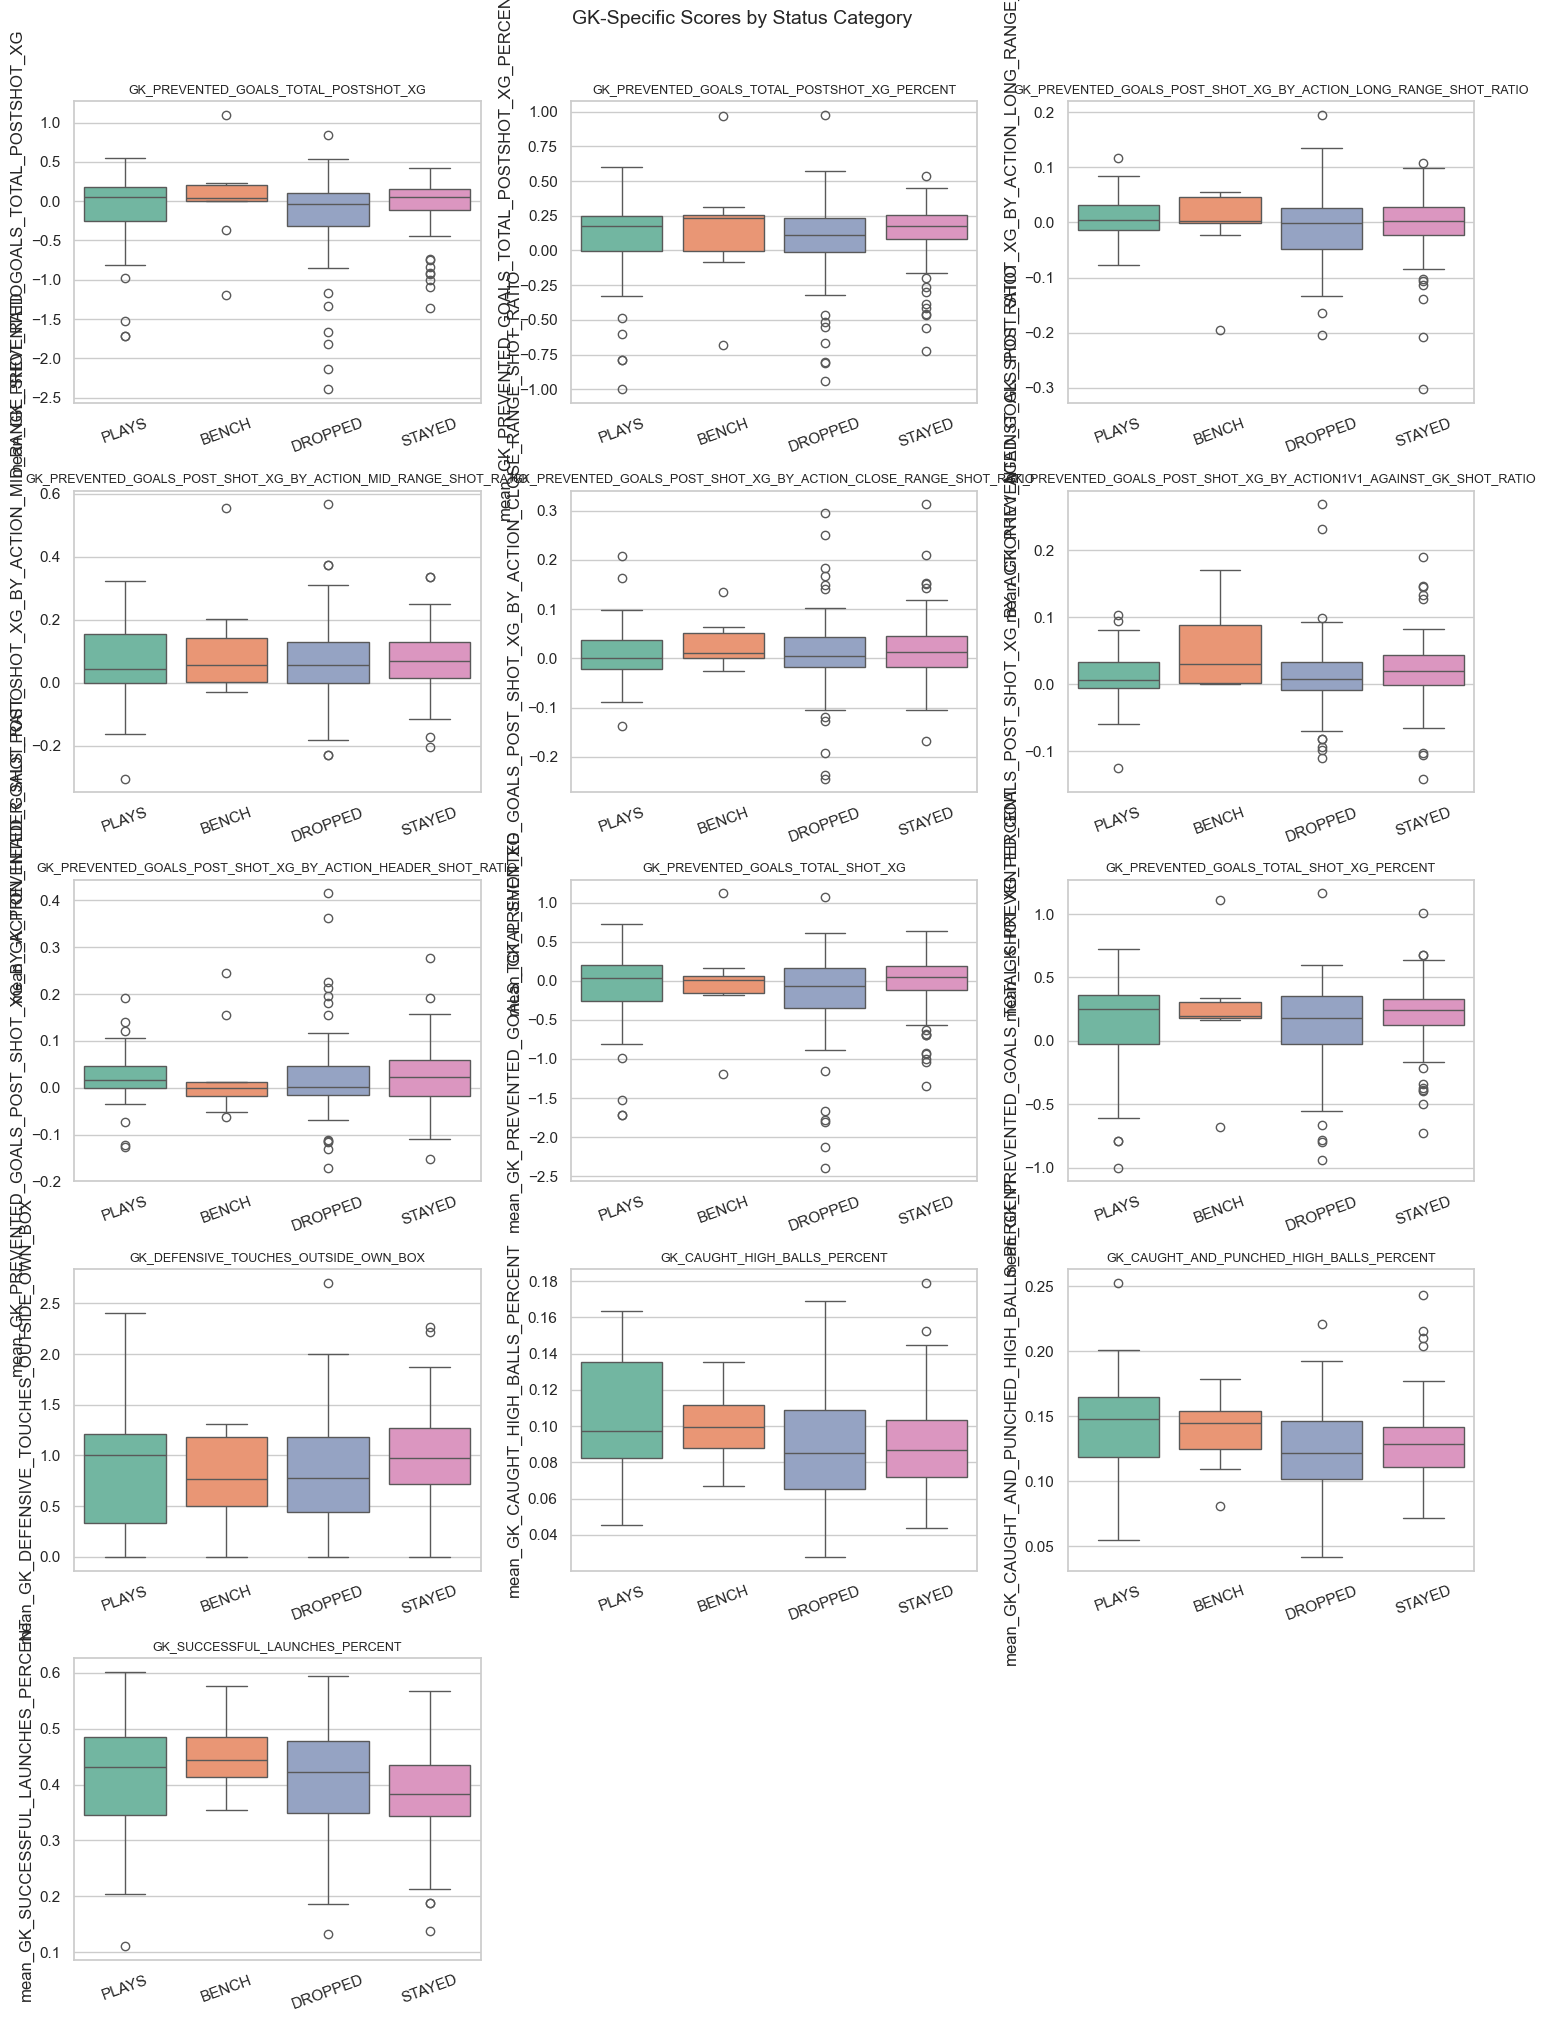

Plot saved to gk_scores_by_status.png


In [15]:
# GK specific score IDs
GK_SCORE_IDS = [164, 166, 167, 168, 169, 170, 171, 184, 186, 189, 190, 191, 192]

gk_plot_cols = []
for sid in GK_SCORE_IDS:
    name = score_defs.get(sid, f'SCORE_{sid}')
    col = f'mean_{name}'
    if col in features_df.columns:
        gk_plot_cols.append((col, name))

print(f'GK-specific score columns found: {len(gk_plot_cols)}')

if gk_plot_cols:
    n = len(gk_plot_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
    axes = axes.flatten()

    status_order = ['PLAYS', 'BENCH', 'DROPPED', 'STAYED']

    for i, (col, name) in enumerate(gk_plot_cols):
        plot_data = features_df.dropna(subset=[col])
        sns.boxplot(data=plot_data, x='status', y=col, order=status_order,
                    ax=axes[i], palette='Set2')
        axes[i].set_title(name, fontsize=9, wrap=True)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=20)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('GK-Specific Scores by Status Category', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('gk_scores_by_status.png', bbox_inches='tight', dpi=120)
    plt.show()
    print('Plot saved to gk_scores_by_status.png')
else:
    print('No GK-specific score columns found — they may be absent due to season coverage.')
    print('Falling back to general scores (see next cell).')

General score columns with good coverage: 10


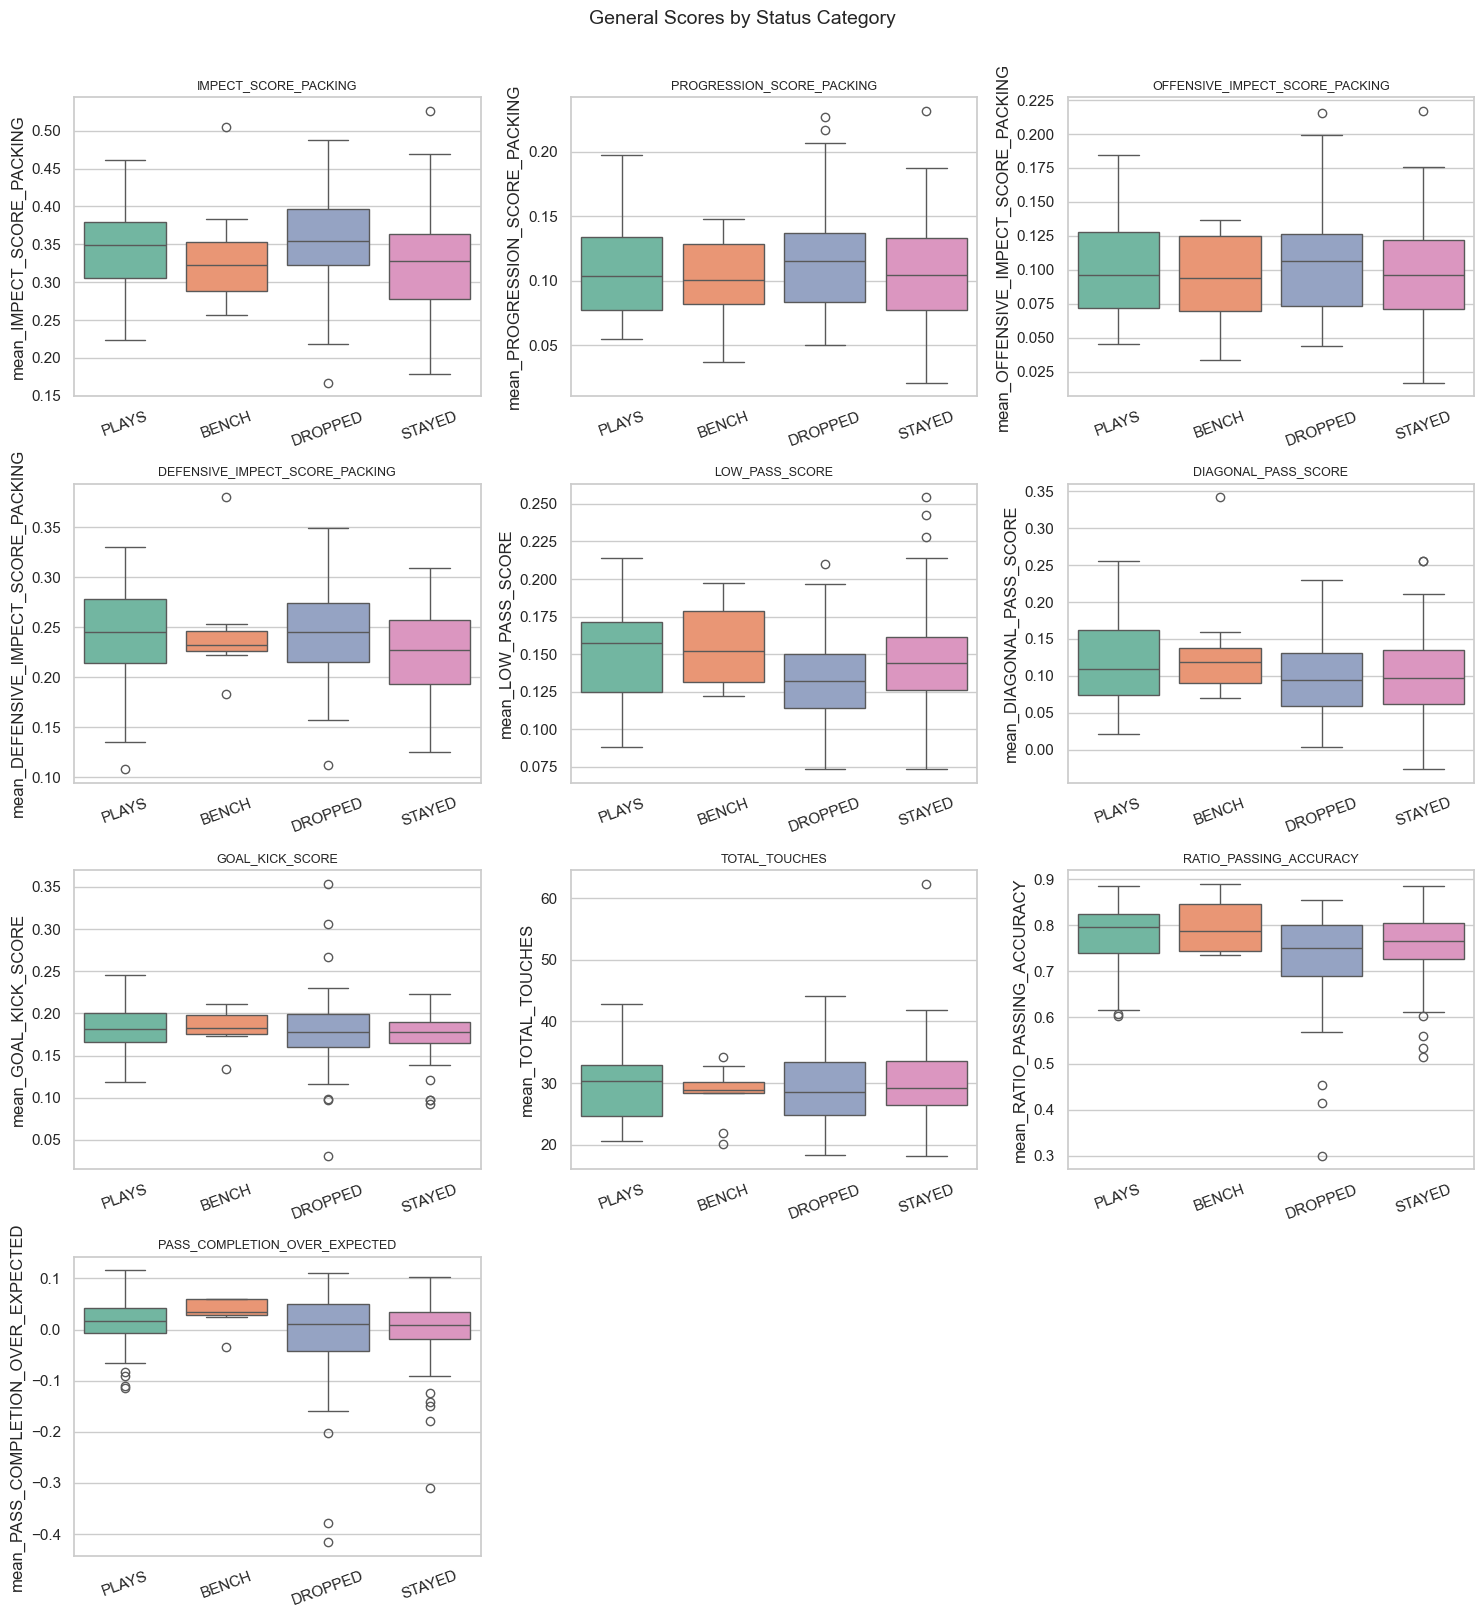

In [16]:
# General scores with good coverage
GENERAL_SCORE_IDS = [0, 9, 10, 17, 52, 55, 81, 101, 163, 232]

general_plot_cols = []
for sid in GENERAL_SCORE_IDS:
    name = score_defs.get(sid, f'SCORE_{sid}')
    col = f'mean_{name}'
    if col in features_df.columns and features_df[col].notna().sum() > 50:
        general_plot_cols.append((col, name))

print(f'General score columns with good coverage: {len(general_plot_cols)}')

if general_plot_cols:
    n = len(general_plot_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 4))
    axes = axes.flatten()

    status_order = ['PLAYS', 'BENCH', 'DROPPED', 'STAYED']

    for i, (col, name) in enumerate(general_plot_cols):
        plot_data = features_df.dropna(subset=[col])
        sns.boxplot(data=plot_data, x='status', y=col, order=status_order,
                    ax=axes[i], palette='Set2')
        axes[i].set_title(name, fontsize=9)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=20)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('General Scores by Status Category', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('general_scores_by_status.png', bbox_inches='tight', dpi=120)
    plt.show()

---
## Step 3 · Feature Selection

We run feature selection **twice**, once targeting `y_plays` (regular starter) and once targeting `y_up` (any game time at a higher level). This produces two separate feature sets that will each be used to train three models in Step 4.

The pipeline for each target is:
1. **Curated GK feature list**: restrict to GK-relevant score IDs (avoids outfield noise)
2. **Missing-value filter**: drop columns missing in >40% of keepers
3. **Mutual information ranking**: rank remaining features by predictive relevance
4. **Correlation deduplication**: drop the weaker of any pair with |r| > 0.85

### 3a · GK feature list (shared)

Both targets start from the same set of GK-relevant score IDs. This avoids MI picking up outfield scores that are near-zero for every goalkeeper and produce spurious signal.

In [17]:
GK_SCORE_IDS = {
    # Shot stopping (post-shot xG — strongest signal per briefing)
    164: 'GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG',
    166: 'GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG_PERCENT',
    167: 'GK_PREVENTED_GOALS_LONG_RANGE_RATIO',
    168: 'GK_PREVENTED_GOALS_MID_RANGE_RATIO',
    169: 'GK_PREVENTED_GOALS_CLOSE_RANGE_RATIO',
    170: 'GK_PREVENTED_GOALS_1V1_RATIO',
    171: 'GK_PREVENTED_GOALS_HEADERS_RATIO',
    184: 'GK_PREVENTED_GOALS_TOTAL_SHOT_XG',
    186: 'GK_PREVENTED_GOALS_TOTAL_SHOT_XG_PERCENT',
    # Aerial and sweeping
    189: 'GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX',
    190: 'GK_CAUGHT_HIGH_BALLS_PERCENT',
    191: 'GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT',
    # Distribution
    192: 'GK_SUCCESSFUL_LAUNCHES_PERCENT',
    81:  'GOAL_KICK_SCORE',
    52:  'LOW_PASS_SCORE',
    55:  'DIAGONAL_PASS_SCORE',
    163: 'RATIO_PASSING_ACCURACY',
    232: 'PASS_COMPLETION_OVER_EXPECTED',
    # Overall
    0:   'IMPECT_SCORE_PACKING',
    17:  'DEFENSIVE_IMPECT_SCORE_PACKING',
    101: 'TOTAL_TOUCHES',
}

context_cols = ['age', 'origin_median', 'n_matches_loaded']

gk_feature_cols = []
for sid, fallback_name in GK_SCORE_IDS.items():
    readable = score_defs.get(sid, fallback_name)
    col = f'mean_{readable}'
    if col in features_df.columns:
        gk_feature_cols.append(col)
    else:
        print(f'  [missing] {col}')

print(f'Curated GK feature columns : {len(gk_feature_cols)} / {len(GK_SCORE_IDS)}')
print(f'Context columns            : {context_cols}')

Curated GK feature columns : 21 / 21
Context columns            : ['age', 'origin_median', 'n_matches_loaded']


### 3b · Feature selection helper

A single function that runs the full pipeline (missing filter, MI ranking, correlation) for any given target variable. Called once for `y_plays` and once for `y_up`.

In [18]:
MISSING_THRESHOLD = 0.40

def select_features(target_values, target_name):
    X_raw = features_df[context_cols + gk_feature_cols].copy()

    # Step 1: drop columns missing in >40% of keepers
    missing_rate = X_raw.isna().mean()
    keep_cols    = missing_rate[missing_rate <= MISSING_THRESHOLD].index.tolist()
    X_filtered   = X_raw[keep_cols].fillna(X_raw[keep_cols].median())

    # Step 2: mutual information ranking
    mi_scores = mutual_info_classif(X_filtered, target_values,
                                    discrete_features=False, random_state=42)
    mi_series = pd.Series(mi_scores, index=X_filtered.columns).sort_values(ascending=False)

    # Step 3: drop weaker of each highly correlated pair (|r| > 0.85)
    score_cols = [c for c in X_filtered.columns if c.startswith('mean_')]
    corr       = X_filtered[score_cols].corr()
    high_corr  = [
        (corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3))
        for i in range(len(corr.columns))
        for j in range(i + 1, len(corr.columns))
        if abs(corr.iloc[i, j]) > 0.85
    ]
    to_drop = set()
    for a, b, r in high_corr:
        if a not in to_drop and b not in to_drop:
            drop = b if mi_series.get(a, 0) >= mi_series.get(b, 0) else a
            to_drop.add(drop)

    final_cols = [c for c in X_filtered.columns if c not in to_drop]
    X_final    = X_filtered[final_cols]

    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  Feature selection — target: {target_name}')
    print(sep)
    print(f'  Columns after missing filter : {X_filtered.shape[1]}')
    print(f'  High-corr pairs dropped      : {len(to_drop)}')
    print(f'  Final feature count          : {len(final_cols)}')
    print()
    print('  MI ranking:')
    for c in final_cols:
        mi_val = mi_series.get(c, 0)
        marker = ' *' if mi_val > 0 else ''
        print(f'    {mi_val:.4f}  {c.replace("mean_", "")}{marker}')

    return X_final.values, final_cols, mi_series


print('select_features() defined ✓')

select_features() defined ✓


### 3c · Feature selection for `y_plays`

Target: PLAYS vs BENCH + STAYED + DROPPED

In [19]:
y_plays = features_df['y_plays'].values
y_up    = features_df['y_up'].values

X_plays, feature_cols_plays, mi_plays = select_features(y_plays, 'y_plays')


  Feature selection — target: y_plays
  Columns after missing filter : 24
  High-corr pairs dropped      : 4
  Final feature count          : 20

  MI ranking:
    0.0000  age
    0.0265  origin_median *
    0.0000  n_matches_loaded
    0.0000  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG
    0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_LONG_RANGE_SHOT_RATIO
    0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_MID_RANGE_SHOT_RATIO
    0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_CLOSE_RANGE_SHOT_RATIO
    0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION1V1_AGAINST_GK_SHOT_RATIO
    0.0357  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_HEADER_SHOT_RATIO *
    0.0309  GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX *
    0.0642  GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT *
    0.0065  GK_SUCCESSFUL_LAUNCHES_PERCENT *
    0.0000  GOAL_KICK_SCORE
    0.0080  LOW_PASS_SCORE *
    0.0000  DIAGONAL_PASS_SCORE
    0.0351  RATIO_PASSING_ACCURACY *
    0.0000  PASS_COMPLETION_OVER_EXPECTED
    0.0074  IMPEC

### 3d · Feature selection for `y_up`

Target: PLAYS + BENCH vs STAYED + DROPPED

In [20]:
X_up, feature_cols_up, mi_up = select_features(y_up, 'y_up')


  Feature selection — target: y_up
  Columns after missing filter : 24
  High-corr pairs dropped      : 4
  Final feature count          : 20

  MI ranking:
    0.0000  age
    0.0600  origin_median *
    0.0000  n_matches_loaded
    0.0000  GK_PREVENTED_GOALS_TOTAL_POSTSHOT_XG
    0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_LONG_RANGE_SHOT_RATIO
    0.0178  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_MID_RANGE_SHOT_RATIO *
    0.0000  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_CLOSE_RANGE_SHOT_RATIO
    0.0067  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION1V1_AGAINST_GK_SHOT_RATIO *
    0.0204  GK_PREVENTED_GOALS_POST_SHOT_XG_BY_ACTION_HEADER_SHOT_RATIO *
    0.0058  GK_DEFENSIVE_TOUCHES_OUTSIDE_OWN_BOX *
    0.0744  GK_CAUGHT_AND_PUNCHED_HIGH_BALLS_PERCENT *
    0.0351  GK_SUCCESSFUL_LAUNCHES_PERCENT *
    0.0088  GOAL_KICK_SCORE *
    0.0276  LOW_PASS_SCORE *
    0.0234  DIAGONAL_PASS_SCORE *
    0.0184  RATIO_PASSING_ACCURACY *
    0.0042  PASS_COMPLETION_OVER_EXPECTED *
    0.0035

### 3e · MI rankings — side by side comparison

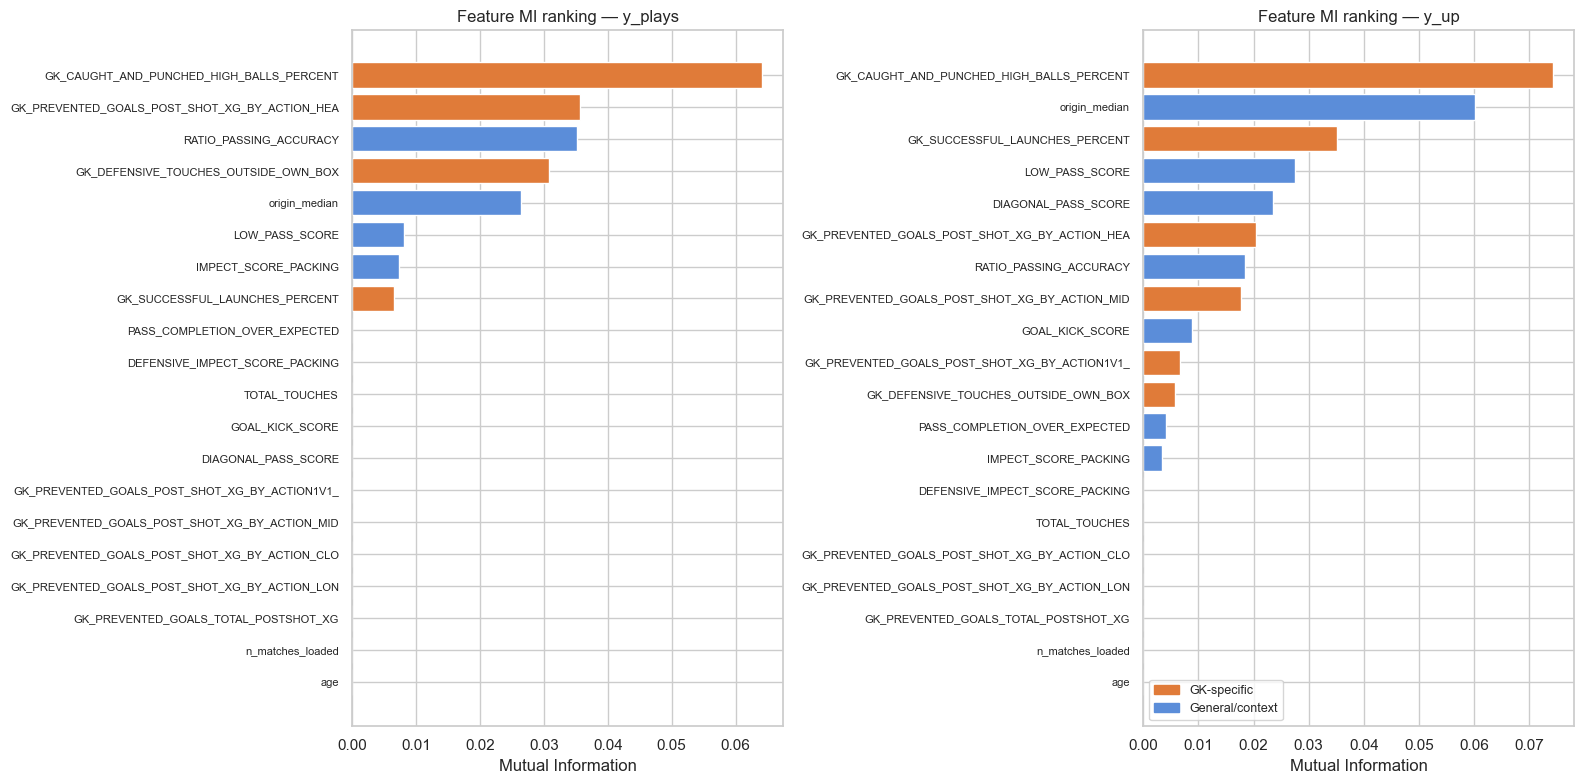

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(feature_cols_plays) * 0.4)))

for ax, mi_s, fcols, title in [
    (axes[0], mi_plays, feature_cols_plays, 'y_plays'),
    (axes[1], mi_up,    feature_cols_up,    'y_up'),
]:
    # only show features in the final selected set
    mi_plot = mi_s[fcols].sort_values()
    colors  = ['#e07b39' if 'GK_' in c else '#5b8dd9' for c in mi_plot.index]
    ax.barh(range(len(mi_plot)), mi_plot.values, color=colors)
    ax.set_yticks(range(len(mi_plot)))
    ax.set_yticklabels([c.replace('mean_', '')[:45] for c in mi_plot.index], fontsize=8)
    ax.set_xlabel('Mutual Information')
    ax.set_title(f'Feature MI ranking — {title}')

from matplotlib.patches import Patch
legend = [Patch(color='#e07b39', label='GK-specific'), Patch(color='#5b8dd9', label='General/context')]
axes[1].legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.savefig('mi_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

### 3f · Save feature matrices

In [22]:
# Save both feature matrices to CSV for Step 4
save_df = features_df[['playerId', 'name', 'status', 'direction', 'y_plays', 'y_up']].copy()

plays_df = pd.concat([save_df.reset_index(drop=True),
                       pd.DataFrame(X_plays, columns=feature_cols_plays)], axis=1)
plays_df.to_csv('gk_features_plays.csv', index=False)

up_df = pd.concat([save_df.reset_index(drop=True),
                   pd.DataFrame(X_up, columns=feature_cols_up)], axis=1)
up_df.to_csv('gk_features_up.csv', index=False)

print(f'gk_features_plays.csv — shape: {plays_df.shape}  (features: {len(feature_cols_plays)})')
print(f'gk_features_up.csv    — shape: {up_df.shape}  (features: {len(feature_cols_up)})')
print()
print(f'y_plays positive rate : {y_plays.mean():.1%}  ({y_plays.sum()} PLAYS)')
print(f'y_up    positive rate : {y_up.mean():.1%}  ({y_up.sum()} PLAYS+BENCH)')

gk_features_plays.csv — shape: (218, 26)  (features: 20)
gk_features_up.csv    — shape: (218, 26)  (features: 20)

y_plays positive rate : 17.0%  (37 PLAYS)
y_up    positive rate : 21.1%  (46 PLAYS+BENCH)


---
## Step 4 · Modelling

We train three models on **each** feature set:

| | Target | Feature set | Positive class |
|---|---|---|---|
| **y_plays models** | `y_plays` | `feature_cols_plays` | PLAYS (≥5 matches) |
| **y_up models** | `y_up` | `feature_cols_up` | PLAYS + BENCH |

The three models are: Logistic Regression, Random Forest, and XGBoost.
All use class balancing. Evaluation uses stratified 5-fold CV.

### 4a · Imports & CV setup

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

CV      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = ['roc_auc', 'average_precision', 'f1', 'precision', 'recall']

def summarise_cv(cv_results, model_name):
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  {model_name}')
    print(f'{sep}')
    for metric in SCORING:
        vals = cv_results[f'test_{metric}']
        print(f'  {metric:<22}  {vals.mean():.3f}  ± {vals.std():.3f}')

def comparison_table(results_dict, title):
    rows = []
    for name, cv_res in results_dict.items():
        rows.append({
            'Model'        : name,
            'AUC-ROC'      : f"{cv_res['test_roc_auc'].mean():.3f} ± {cv_res['test_roc_auc'].std():.3f}",
            'Avg Precision': f"{cv_res['test_average_precision'].mean():.3f} ± {cv_res['test_average_precision'].std():.3f}",
            'F1'           : f"{cv_res['test_f1'].mean():.3f} ± {cv_res['test_f1'].std():.3f}",
            'Precision'    : f"{cv_res['test_precision'].mean():.3f} ± {cv_res['test_precision'].std():.3f}",
            'Recall'       : f"{cv_res['test_recall'].mean():.3f} ± {cv_res['test_recall'].std():.3f}",
        })
    df = pd.DataFrame(rows).set_index('Model')
    print(f'\n=== {title} ===')
    print(df.to_string())
    return df

print('CV setup ready ✓')

CV setup ready ✓


### 4b · y_plays models

Target: PLAYS vs rest. Feature set: `feature_cols_plays`.

In [24]:
# Use the feature matrix from Step 3
X      = X_plays
y      = y_plays

# Logistic Regression
lr_plays = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_cv_plays = cross_validate(lr_plays, X, y, cv=CV, scoring=SCORING)
summarise_cv(lr_cv_plays, 'Logistic Regression — y_plays')

# Random Forest
rf_plays = RandomForestClassifier(
    n_estimators=500, class_weight='balanced',
    max_features='sqrt', min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
rf_cv_plays = cross_validate(rf_plays, X, y, cv=CV, scoring=SCORING)
summarise_cv(rf_cv_plays, 'Random Forest — y_plays')

# XGBoost
spw_plays = int((y == 0).sum()) / int((y == 1).sum())
xgb_plays = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_plays,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_cv_plays = cross_validate(xgb_plays, X, y, cv=CV, scoring=SCORING)
summarise_cv(xgb_cv_plays, 'XGBoost — y_plays')


  Logistic Regression — y_plays
  roc_auc                 0.623  ± 0.105
  average_precision       0.351  ± 0.145
  f1                      0.327  ± 0.110
  precision               0.245  ± 0.082
  recall                  0.514  ± 0.167

  Random Forest — y_plays
  roc_auc                 0.609  ± 0.052
  average_precision       0.266  ± 0.030
  f1                      0.000  ± 0.000
  precision               0.000  ± 0.000
  recall                  0.000  ± 0.000

  XGBoost — y_plays
  roc_auc                 0.530  ± 0.093
  average_precision       0.216  ± 0.056
  f1                      0.027  ± 0.053
  precision               0.025  ± 0.050
  recall                  0.029  ± 0.057


### 4c · y_plays comparison table

In [25]:
results_plays = {
    'Logistic Regression': lr_cv_plays,
    'Random Forest'      : rf_cv_plays,
    'XGBoost'            : xgb_cv_plays,
}
comp_plays = comparison_table(results_plays, 'y_plays results')


=== y_plays results ===
                           AUC-ROC  Avg Precision             F1      Precision         Recall
Model                                                                                         
Logistic Regression  0.623 ± 0.105  0.351 ± 0.145  0.327 ± 0.110  0.245 ± 0.082  0.514 ± 0.167
Random Forest        0.609 ± 0.052  0.266 ± 0.030  0.000 ± 0.000  0.000 ± 0.000  0.000 ± 0.000
XGBoost              0.530 ± 0.093  0.216 ± 0.056  0.027 ± 0.053  0.025 ± 0.050  0.029 ± 0.057


### 4d · y_up models

Target: PLAYS + BENCH vs rest. Feature set: `feature_cols_up`.

In [26]:
X_up_arr = X_up
y_up_arr = y_up

# Logistic Regression
lr_up = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',   LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_cv_up = cross_validate(lr_up, X_up_arr, y_up_arr, cv=CV, scoring=SCORING)
summarise_cv(lr_cv_up, 'Logistic Regression — y_up')

# Random Forest
rf_up = RandomForestClassifier(
    n_estimators=500, class_weight='balanced',
    max_features='sqrt', min_samples_leaf=3,
    random_state=42, n_jobs=-1
)
rf_cv_up = cross_validate(rf_up, X_up_arr, y_up_arr, cv=CV, scoring=SCORING)
summarise_cv(rf_cv_up, 'Random Forest — y_up')

# XGBoost
spw_up = int((y_up_arr == 0).sum()) / int((y_up_arr == 1).sum())
xgb_up = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_up,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_cv_up = cross_validate(xgb_up, X_up_arr, y_up_arr, cv=CV, scoring=SCORING)
summarise_cv(xgb_cv_up, 'XGBoost — y_up')


  Logistic Regression — y_up
  roc_auc                 0.640  ± 0.098
  average_precision       0.488  ± 0.156
  f1                      0.431  ± 0.107
  precision               0.350  ± 0.104
  recall                  0.584  ± 0.152

  Random Forest — y_up
  roc_auc                 0.669  ± 0.060
  average_precision       0.402  ± 0.082
  f1                      0.169  ± 0.099
  precision               0.467  ± 0.323
  recall                  0.109  ± 0.070

  XGBoost — y_up
  roc_auc                 0.630  ± 0.092
  average_precision       0.364  ± 0.095
  f1                      0.259  ± 0.162
  precision               0.351  ± 0.156
  recall                  0.220  ± 0.174


### 4e · y_up comparison table

In [27]:
results_up_dict = {
    'Logistic Regression': lr_cv_up,
    'Random Forest'      : rf_cv_up,
    'XGBoost'            : xgb_cv_up,
}
comp_up = comparison_table(results_up_dict, 'y_up results')


=== y_up results ===
                           AUC-ROC  Avg Precision             F1      Precision         Recall
Model                                                                                         
Logistic Regression  0.640 ± 0.098  0.488 ± 0.156  0.431 ± 0.107  0.350 ± 0.104  0.584 ± 0.152
Random Forest        0.669 ± 0.060  0.402 ± 0.082  0.169 ± 0.099  0.467 ± 0.323  0.109 ± 0.070
XGBoost              0.630 ± 0.092  0.364 ± 0.095  0.259 ± 0.162  0.351 ± 0.156  0.220 ± 0.174


### 4f · Head to head: y_plays vs y_up (AUC-ROC)

In [28]:
print('=== AUC-ROC: y_plays vs y_up ===\n')
sep = '-' * 52
print(f"{'Model':<25} {'y_plays':>9} {'y_up':>9} {'diff':>8}")
print(sep)

pairs = [
    ('Logistic Regression', lr_cv_plays,  lr_cv_up),
    ('Random Forest',       rf_cv_plays,  rf_cv_up),
    ('XGBoost',             xgb_cv_plays, xgb_cv_up),
]

for name, cv_p, cv_u in pairs:
    auc_p = cv_p['test_roc_auc'].mean()
    auc_u = cv_u['test_roc_auc'].mean()
    diff  = auc_u - auc_p
    print(f'{name:<25} {auc_p:>9.3f} {auc_u:>9.3f} {diff:>+8.3f}')

=== AUC-ROC: y_plays vs y_up ===

Model                       y_plays      y_up     diff
----------------------------------------------------
Logistic Regression           0.623     0.640   +0.016
Random Forest                 0.609     0.669   +0.060
XGBoost                       0.530     0.630   +0.100


### 4g · ROC curves, y_plays vs y_up

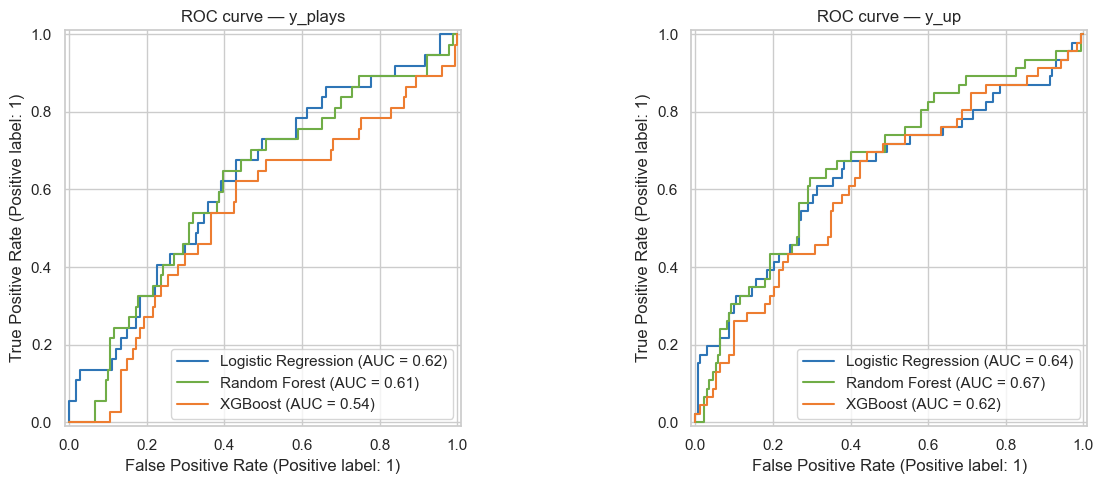

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

specs = [
    (axes[0], X_plays,  y_plays,  'y_plays',
     [('Logistic Regression', lr_plays,  '#2E75B6'),
      ('Random Forest',       rf_plays,  '#70AD47'),
      ('XGBoost',             xgb_plays, '#ED7D31')]),
    (axes[1], X_up_arr, y_up_arr, 'y_up',
     [('Logistic Regression', lr_up,  '#2E75B6'),
      ('Random Forest',       rf_up,  '#70AD47'),
      ('XGBoost',             xgb_up, '#ED7D31')]),
]

for ax, X_t, y_t, title, model_list in specs:
    for name, model, color in model_list:
        proba = cross_val_predict(model, X_t, y_t, cv=CV, method='predict_proba')[:, 1]
        RocCurveDisplay.from_predictions(y_t, proba, name=name, ax=ax, color=color)
    ax.set_title(f'ROC curve — {title}')

plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()

### 4h · Feature importance, Logistic Regression coefficients

Logistic Regression is the best-performing model (from results above). Standardised coefficients show which features push predictions toward the positive class.

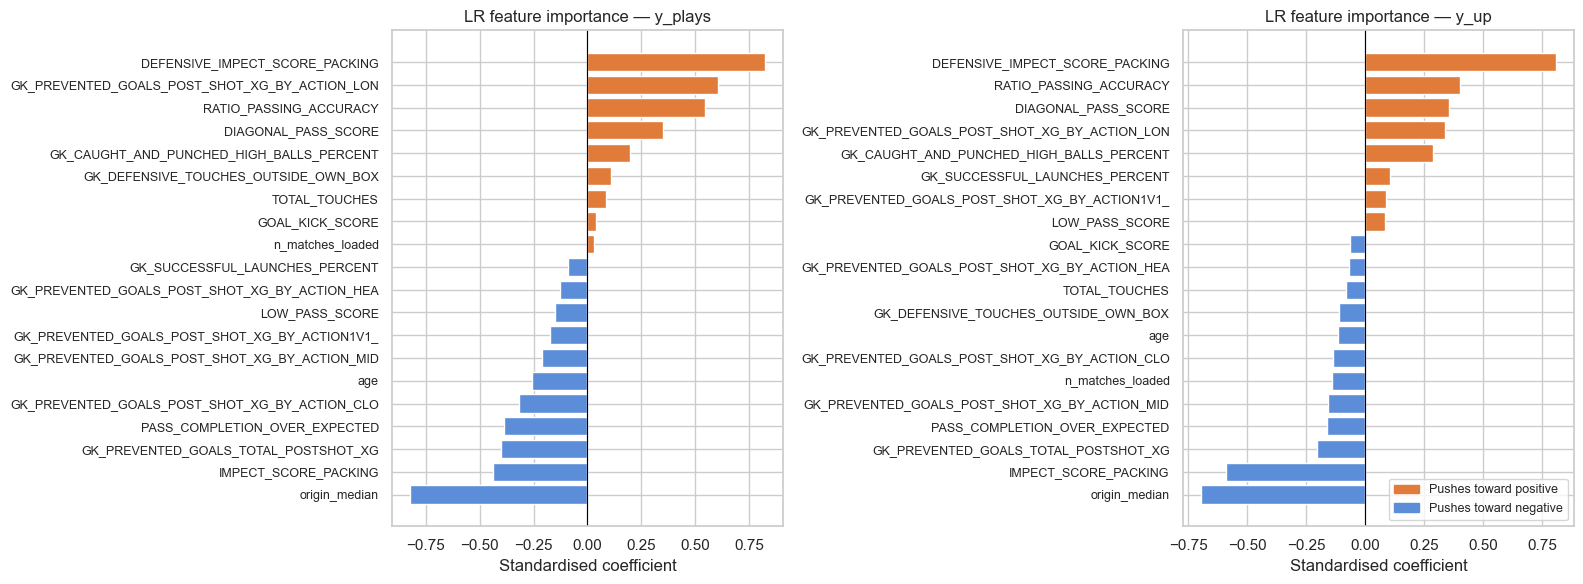

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, X_t, y_t, fcols, title in [
    (axes[0], lr_plays,  X_plays,  y_plays,  feature_cols_plays, 'y_plays'),
    (axes[1], lr_up,     X_up_arr, y_up_arr, feature_cols_up,    'y_up'),
]:
    model.fit(X_t, y_t)
    coefs = pd.Series(
        model.named_steps['clf'].coef_[0],
        index=[c.replace('mean_', '') for c in fcols]
    ).sort_values()

    colors = ['#e07b39' if v > 0 else '#5b8dd9' for v in coefs.values]
    ax.barh(range(len(coefs)), coefs.values, color=colors)
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels([c[:45] for c in coefs.index], fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Standardised coefficient')
    ax.set_title(f'LR feature importance — {title}')

from matplotlib.patches import Patch
legend = [Patch(color='#e07b39', label='Pushes toward positive'),
          Patch(color='#5b8dd9', label='Pushes toward negative')]
axes[1].legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

---
## Step 5 · Validation

We validate the **best model (Logistic Regression)** for both targets.

All predictions are **out-of-fold** — every keeper's score was produced by a model that never saw that keeper during training.

### 5a · Per-fold stability

Checks whether CV scores are consistent across folds or driven by one lucky split.

In [31]:
def fold_stability(model, X_t, y_t, label):
    records = []
    for fold, (tr, te) in enumerate(CV.split(X_t, y_t), 1):
        model.fit(X_t[tr], y_t[tr])
        proba = model.predict_proba(X_t[te])[:, 1]
        preds = model.predict(X_t[te])
        from sklearn.metrics import f1_score, precision_score, recall_score
        records.append({
            'Fold'     : fold,
            'n_pos'    : int(y_t[te].sum()),
            'AUC-ROC'  : round(roc_auc_score(y_t[te], proba), 3),
            'Avg Prec' : round(average_precision_score(y_t[te], proba), 3),
            'F1'       : round(f1_score(y_t[te], preds, zero_division=0), 3),
            'Recall'   : round(recall_score(y_t[te], preds, zero_division=0), 3),
        })
    df = pd.DataFrame(records).set_index('Fold')
    print(f'\n--- {label} ---')
    print(df.to_string())
    print(f'Mean AUC: {df["AUC-ROC"].mean():.3f}  Std: {df["AUC-ROC"].std():.3f}')

fold_stability(lr_plays, X_plays,  y_plays,  'Logistic Regression — y_plays')
fold_stability(lr_up,    X_up_arr, y_up_arr, 'Logistic Regression — y_up')


--- Logistic Regression — y_plays ---
      n_pos  AUC-ROC  Avg Prec     F1  Recall
Fold                                         
1         7    0.514     0.295  0.200   0.429
2         8    0.792     0.620  0.500   0.750
3         8    0.538     0.223  0.222   0.250
4         7    0.694     0.376  0.333   0.571
5         7    0.579     0.240  0.381   0.571
Mean AUC: 0.623  Std: 0.117

--- Logistic Regression — y_up ---
      n_pos  AUC-ROC  Avg Prec     F1  Recall
Fold                                         
1        10    0.682     0.505  0.500   0.700
2         9    0.463     0.219  0.231   0.333
3         9    0.752     0.632  0.483   0.778
4         9    0.683     0.647  0.526   0.556
5         9    0.618     0.438  0.417   0.556
Mean AUC: 0.640  Std: 0.110


### 5b · Classification report, out-of-fold

In [32]:
for model, X_t, y_t, label, pos_label in [
    (lr_plays, X_plays,  y_plays,  'y_plays', 'PLAYS'),
    (lr_up,    X_up_arr, y_up_arr, 'y_up',    'PLAYS+BENCH'),
]:
    proba = cross_val_predict(model, X_t, y_t, cv=CV, method='predict_proba')[:, 1]
    preds = cross_val_predict(model, X_t, y_t, cv=CV, method='predict')
    sep = '=' * 55
    print(f'\n{sep}')
    print(f'  Logistic Regression — {label}')
    print(sep)
    print(classification_report(y_t, preds,
          target_names=['Other', pos_label], digits=3))
    print(f'  AUC-ROC      : {roc_auc_score(y_t, proba):.3f}')
    print(f'  Avg Precision: {average_precision_score(y_t, proba):.3f}')
    print(f'  Random base  : {y_t.mean():.3f}')


  Logistic Regression — y_plays
              precision    recall  f1-score   support

       Other      0.870     0.663     0.752       181
       PLAYS      0.237     0.514     0.325        37

    accuracy                          0.638       218
   macro avg      0.554     0.588     0.539       218
weighted avg      0.762     0.638     0.680       218

  AUC-ROC      : 0.625
  Avg Precision: 0.294
  Random base  : 0.170

  Logistic Regression — y_up
              precision    recall  f1-score   support

       Other      0.862     0.692     0.768       172
 PLAYS+BENCH      0.338     0.587     0.429        46

    accuracy                          0.670       218
   macro avg      0.600     0.639     0.598       218
weighted avg      0.752     0.670     0.696       218

  AUC-ROC      : 0.644
  Avg Precision: 0.411
  Random base  : 0.211


### 5c · Overfitting check, train vs validation AUC

In [33]:
for model, X_t, y_t, label in [
    (lr_plays, X_plays,  y_plays,  'y_plays'),
    (lr_up,    X_up_arr, y_up_arr, 'y_up'),
]:
    train_aucs, val_aucs = [], []
    for tr, te in CV.split(X_t, y_t):
        model.fit(X_t[tr], y_t[tr])
        train_aucs.append(roc_auc_score(y_t[tr], model.predict_proba(X_t[tr])[:, 1]))
        val_aucs.append(roc_auc_score(y_t[te],   model.predict_proba(X_t[te])[:, 1]))
    gap = np.mean(train_aucs) - np.mean(val_aucs)
    verdict = 'OK' if gap < 0.08 else ('Moderate' if gap < 0.15 else 'High — overfitting')
    print(f'{label:<10}  Train: {np.mean(train_aucs):.3f}  Val: {np.mean(val_aucs):.3f}  '
          f'Gap: {gap:.3f}  [{verdict}]')

y_plays     Train: 0.806  Val: 0.623  Gap: 0.183  [High — overfitting]
y_up        Train: 0.800  Val: 0.640  Gap: 0.160  [High — overfitting]


---
## Final Model

We use **Logistic Regression trained on `y_up`** as the final scouting model.

`y_up` is more appropriate because it asks *is this keeper ready to move up?* rather than mixing keeper quality with playing-time decisions made by the destination club. It also has more positive examples (46 vs 37), giving the model more signal to learn from.

In [34]:
# Final model: Logistic Regression on y_up features
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
final_model.fit(X_up_arr, y_up_arr)

print('Final model fitted on full dataset (target: y_up) ✓')
print(f'Positive class: {y_up_arr.sum()} / {len(y_up_arr)} ({y_up_arr.mean():.1%})')

Final model fitted on full dataset (target: y_up) ✓
Positive class: 46 / 218 (21.1%)


In [ ]:
def predict_goalkeeper(identifier):
    # Find the keeper
    if isinstance(identifier, int):
        row = up_df[up_df['playerId'] == identifier]
    else:
        row = up_df[up_df['name'].str.contains(identifier, case=False, na=False)]

    if len(row) == 0:
        print(f"No goalkeeper found for: '{identifier}'")
        return
    if len(row) > 1:
        print('Multiple matches — picking first:')
        print(row[['playerId', 'name', 'status']].to_string(index=False))
        print()
    row = row.iloc[0]

    feat_values = row[feature_cols_up].values.reshape(1, -1)
    proba       = final_model.predict_proba(feat_values)[0][1]
    prediction  = proba >= 0.5

    if proba >= 0.70:   confidence = 'HIGH'
    elif proba >= 0.50: confidence = 'MODERATE'
    elif proba >= 0.35: confidence = 'BORDERLINE'
    else:               confidence = 'LOW'

    # Feature contributions
    coefs        = final_model.named_steps['clf'].coef_[0]
    feat_scaled  = final_model.named_steps['scaler'].transform(feat_values)[0]
    contributions = pd.Series(coefs * feat_scaled, index=feature_cols_up)
    top_pos = contributions.nlargest(3)
    top_neg = contributions.nsmallest(3)

    actual       = row['y_up']
    actual_label = 'UP (PLAYS or BENCH)' if actual == 1 else 'NOT UP (STAYED or DROPPED)'

    sep = '=' * 58
    print(sep)
    print(f"  SCOUTING REPORT — {row['name'].upper()}")
    print(sep)
    print(f"  Player ID      : {row['playerId']}")
    print(f"  Known status   : {row['status']}  →  {actual_label}")
    print(f"  Matches loaded : {int(row['n_matches_loaded'])}")
    print()
    print(f"  QUESTION       : Ready to move up a league?")
    print(f"  PREDICTION     : {'YES' if prediction else 'NO'}")
    print(f"  Probability    : {proba:.1%}")
    print(f"  Confidence     : {confidence}")
    print()
    print('  Top factors FOR moving up:')
    for feat, val in top_pos.items():
        print(f"    + {feat.replace('mean_','').replace('_',' ')[:48]:<48}  ({val:+.3f})")
    print()
    print('  Top factors AGAINST moving up:')
    for feat, val in top_neg.items():
        print(f"    - {feat.replace('mean_','').replace('_',' ')[:48]:<48}  ({val:+.3f})")
    print()
    correct = (prediction == bool(actual))
    print(f"  Model correct  : {'YES' if correct else 'NO'}  (actual: {actual_label})")
    print(sep)


# Call
predict_goalkeeper('Unbehaun')


  SCOUTING REPORT — LUCA UNBEHAUN
  Player ID      : 5674
  Known status   : DROPPED  →  NOT UP (STAYED or DROPPED)
  Matches loaded : 24

  QUESTION       : Ready to move up a league?
  PREDICTION     : NO
  Probability    : 37.1%
  Confidence     : BORDERLINE

  Top factors FOR moving up:
    + DEFENSIVE IMPECT SCORE PACKING                    (+1.127)
    + origin median                                     (+0.306)
    + RATIO PASSING ACCURACY                            (+0.271)

  Top factors AGAINST moving up:
    - IMPECT SCORE PACKING                              (-1.412)
    - GK PREVENTED GOALS POST SHOT XG BY ACTION LONG R  (-0.329)
    - DIAGONAL PASS SCORE                               (-0.178)

  Model correct  : YES  (actual: NOT UP (STAYED or DROPPED))


In [43]:
def rank_all_goalkeepers(top_n=20, min_matches=3, status_filter=None):
    results = []

    for _, row in up_df.iterrows():
        if row['n_matches_loaded'] < min_matches:
            continue
        if status_filter and row['status'] not in status_filter:
            continue

        feat_values = row[feature_cols_up].values.reshape(1, -1)
        proba = final_model.predict_proba(feat_values)[0][1]

        if proba >= 0.70:   confidence = 'HIGH'
        elif proba >= 0.50: confidence = 'MODERATE'
        elif proba >= 0.35: confidence = 'BORDERLINE'
        else:               confidence = 'LOW'

        results.append({
            'Name'          : row['name'],
            'Status'        : row['status'],
            'Probability'   : round(proba, 3),
            'Confidence'    : confidence,
            'Matches'       : int(row['n_matches_loaded']),
            'Actual y_up'   : int(row['y_up']),
        })

    ranking = pd.DataFrame(results).sort_values('Probability', ascending=False).reset_index(drop=True)
    ranking.index += 1  # start ranking at 1

    sep = '=' * 65
    print(sep)
    print(f'  GOALKEEPER PROGRESSION RANKING  —  Top {top_n}')
    if status_filter:
        print(f'  Filter: {status_filter}')
    print(sep)
    print(ranking.head(top_n).to_string())
    print(sep)
    print(f'Total keepers ranked: {len(ranking)}')
    print(f'Predicted to move up (prob >= 0.5): {(ranking["Probability"] >= 0.5).sum()}')

    return ranking

# Call
full_ranking = rank_all_goalkeepers(top_n=20)

  GOALKEEPER PROGRESSION RANKING  —  Top 20
                  Name  Status  Probability Confidence  Matches  Actual y_up
1         Mike Penders   PLAYS        0.975       HIGH       30            1
2         Ales Mandous   PLAYS        0.963       HIGH       39            1
3          Matus Macik   BENCH        0.942       HIGH        4            1
4       Vilem Fendrich   PLAYS        0.941       HIGH       10            1
5              Pape Sy   BENCH        0.923       HIGH       11            1
6      Justin Heekeren   PLAYS        0.912       HIGH       14            1
7   Ennio van der Gouw   BENCH        0.900       HIGH       26            1
8       Antonín Kinský   PLAYS        0.897       HIGH       32            1
9         Jiri Letacek  STAYED        0.887       HIGH       58            0
10      Stefan Drljaca  STAYED        0.871       HIGH       13            0
11      Jari De Busser   PLAYS        0.811       HIGH       27            1
12       Dominik Holec   PLAYS  